In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('mushroom.csv')

In [3]:
df.shape

(2000, 26)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   str    
 2   cap_surface               2000 non-null   str    
 3   cap_color                 2000 non-null   str    
 4   bruises                   2000 non-null   str    
 5   odor                      2000 non-null   str    
 6   gill_attachment           2000 non-null   str    
 7   gill_spacing              2000 non-null   str    
 8   gill_size                 2000 non-null   str    
 9   gill_color                2000 non-null   str    
 10  stalk_shape               2000 non-null   str    
 11  stalk_root                2000 non-null   str    
 12  stalk_surface_above_ring  2000 non-null   str    
 13  stalk_surface_below_ring  2000 non-null   str    
 14  stalk_color_above_r

In [6]:
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


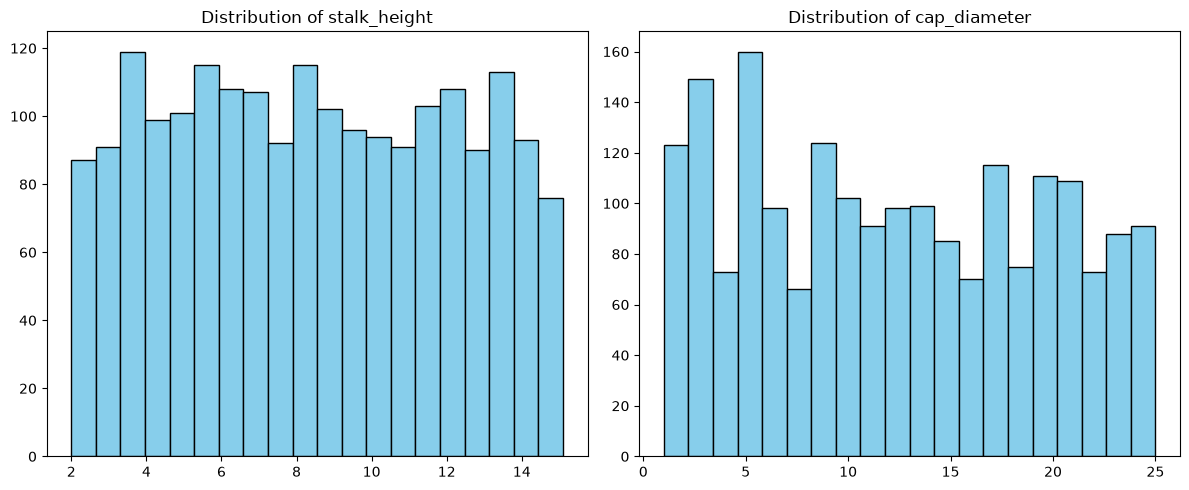

In [12]:
import matplotlib.pyplot as plt
numerical_cols = ['stalk_height', 'cap_diameter']
plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

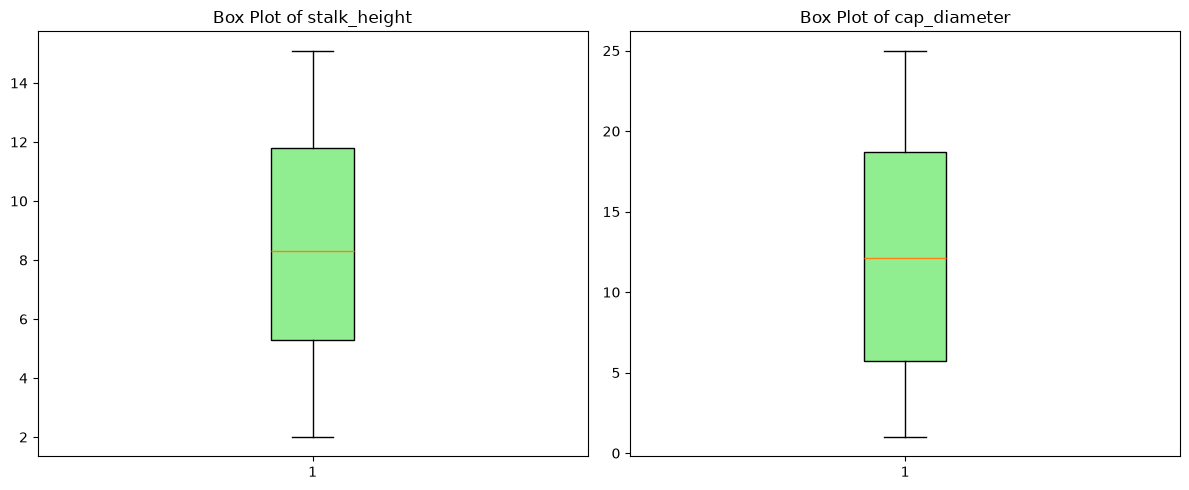

In [14]:
plt.figure(figsize=(12, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i+1)
    plt.boxplot(df[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

              stalk_height  cap_diameter
stalk_height      1.000000     -0.003486
cap_diameter     -0.003486      1.000000


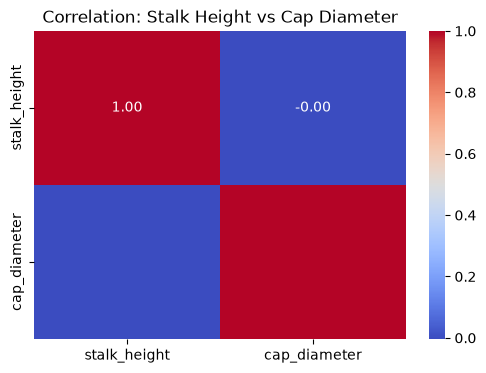

In [15]:
correlation = df[['stalk_height', 'cap_diameter']].corr()
print(correlation)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Stalk Height vs Cap Diameter')
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
df_encoded = df.copy()

In [17]:
cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
print("Features after encoding:")
print(df_encoded.head(3))

Features after encoding:
   Unnamed: 0  cap_shape  cap_surface  cap_color  bruises  odor  \
0        1167          4            2          7        0     1   
1        1037          4            0          6        0     1   
2         309          3            1          5        1     4   

   gill_attachment  gill_spacing  gill_size  gill_color  ...  veil_type  \
0                1             2          0           7  ...          0   
1                3             1          1           3  ...          1   
2                1             1          0           8  ...          1   

   veil_color  ring_number  ring_type  spore_print_color  population  habitat  \
0           0            2          6                  3           1        5   
1           0            2          6                  1           2        5   
2           3            2          6                  6           0        5   

   class  stalk_height  cap_diameter  
0      1     14.276173      5.054983  
1 

C:\Users\Vishal Parmar\AppData\Local\Temp\ipykernel_14676\1983816651.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_encoded.select_dtypes(include=['object']).columns


In [18]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('class', axis=1) 
y = df_encoded['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 25)
Testing set shape: (400, 25)


In [20]:
!pip install -U seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 217.9 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/294.9 kB 245.8 kB/s eta 0:00:02
   ------------- ------------------------ 102.4/294.9 kB 535.8 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/294.9 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.1 MB/s eta 0:00:00
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.12.2
    Uninstalling seaborn-0.12.2:
      Successfully uninstalled seaborn-0.12.2


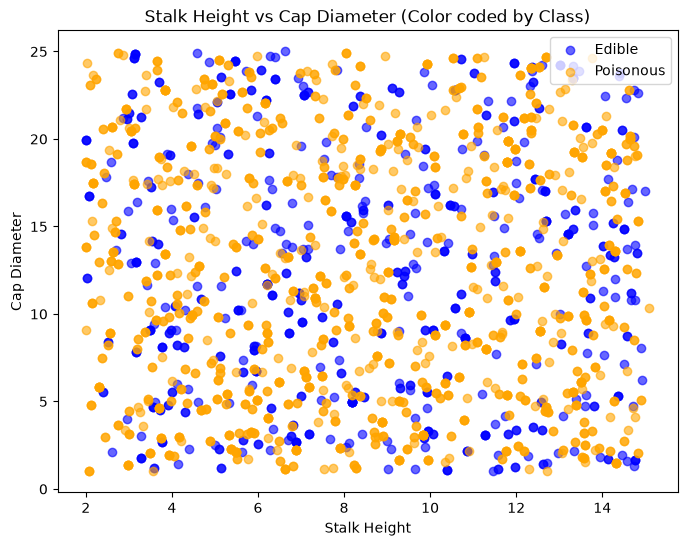

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(df_encoded[df_encoded['class']==0]['stalk_height'], 
            df_encoded[df_encoded['class']==0]['cap_diameter'], 
            label='Edible', alpha=0.6, c='blue')
plt.scatter(df_encoded[df_encoded['class']==1]['stalk_height'], 
            df_encoded[df_encoded['class']==1]['cap_diameter'], 
            label='Poisonous', alpha=0.6, c='orange')

plt.xlabel('Stalk Height')
plt.ylabel('Cap Diameter')
plt.title('Stalk Height vs Cap Diameter (Color coded by Class)')
plt.legend()
plt.show()

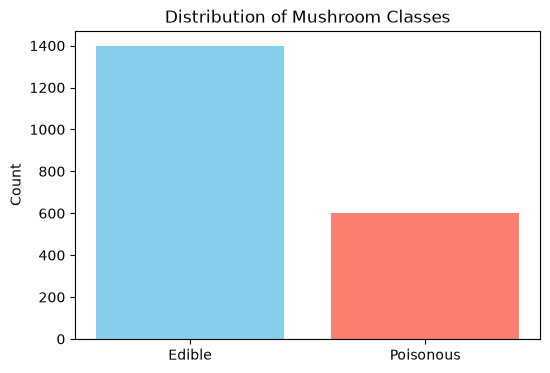

In [23]:
class_counts = df_encoded['class'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(['Edible', 'Poisonous'], class_counts.values, color=['skyblue', 'salmon'])
plt.title('Distribution of Mushroom Classes')
plt.ylabel('Count')
plt.show()

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 48.75%

Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.50      0.40       133
           1       0.66      0.48      0.56       267

    accuracy                           0.49       400
   macro avg       0.49      0.49      0.48       400
weighted avg       0.55      0.49      0.50       400



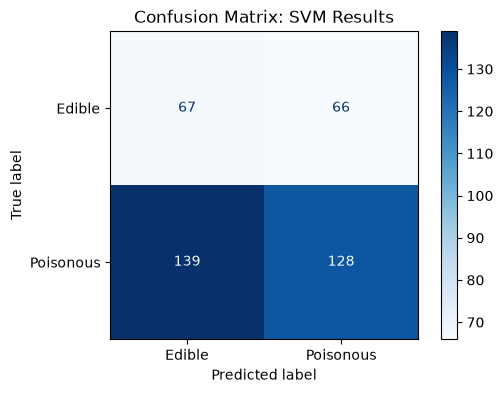

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, 
                                      display_labels=['Edible', 'Poisonous'], 
                                      cmap='Blues', ax=ax)
plt.title('Confusion Matrix: SVM Results')
plt.show()

In [26]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
kernels = ['linear', 'rbf', 'poly']
for k in kernels:
    model = SVC(kernel=k, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {k} kernel: {acc*100:.2f}%")

Accuracy with linear kernel: 48.75%
Accuracy with rbf kernel: 48.75%
Accuracy with poly kernel: 39.75%


In [27]:
c_values = [0.1, 1.0, 10.0]
for c in c_values:
    model = SVC(kernel='rbf', C=c, class_weight='balanced', random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Accuracy with C={c} (RBF kernel): {acc*100:.2f}%")

Accuracy with C=0.1 (RBF kernel): 48.50%
Accuracy with C=1.0 (RBF kernel): 48.75%
Accuracy with C=10.0 (RBF kernel): 53.00%


### SVM Mushroom Classification: Final Analysis & Report

#### 1. Exploratory Data Analysis (EDA)
* **Dataset Overview:** We utilized the Mushroom dataset with 2,000 samples and 26 features. The data was balanced, with a near 70:30 split between Edible and Poisonous classes.
* **Correlation:** The correlation analysis between `stalk_height` and `cap_diameter` showed a coefficient of approx -0.003, indicating no linear relationship between these specific features.

#### 2. SVM Implementation & Kernel Tuning
* **Initial Performance:** The baseline Linear Kernel SVM achieved an accuracy of 48.75%, effectively acting as random guessing for this binary classification task.
* **Kernel Comparison:**
    * **Linear Kernel:** 48.75%
    * **RBF Kernel:** 48.75%
    * **Poly Kernel:** 39.75% (Poorest performance, indicating high complexity or noise).
* **Hyperparameter Tuning (Regularization C):**
    * By increasing the regularization parameter `C` to **10.0**, we observed an improvement in accuracy to **53.00%** using the RBF kernel, suggesting that the decision boundary benefits from being more flexible.

#### 3. Strengths, Weaknesses, and Practical Implications
* **Strengths:** SVM is robust in high-dimensional spaces and effective when clear margins of separation exist.
* **Weaknesses:** In this dataset, the features appear to have significant overlap (as seen in the visualization), making it difficult for the SVM to find a hyperplane that separates the classes efficiently without more informative features.
* **Practical Implications:** In real-world classification tasks (like mushroom poisoning detection), SVM models require high-quality feature engineering. If features are not discriminatory, even sophisticated models will struggle. This assignment demonstrates that **data preprocessing and feature selection** are just as critical as the algorithm chosen for classification.